## 🎲 Eine Setzstrategie gegen alle anderen

Dieses Programm berechnet **exakt** die Gewinnwahrscheinlichkeiten  
$$ P_A(S,T),\ P_B(S,T),\ P_U(S,T) $$,  
wobei $S$ fest gewählt wird und $T$ für alle möglichen Setzstragegien mit gleicher Chipanzahl wie $S$ steht.
- Die Strategie $S$ wird ausgewählt. Damit werden nun alle möglichen Setzstrategien mit gleicher Chipanzahl generiert.
- Es werden sämtliche gestapelten Balkendiagramme für $P_A(S,T)$ und $P_B(S,T)$ 
dargestellt.
- Die berechneten Werte werden in einer CSV-Datei gespeichert.
- Der Plot wird als Grafik im PDF-Format (veränderbar) gespeichert.
- Für mehr als 28 Setzstrategien überlappen sich die Ausgaben für die $x$-Achse. Es empfiehlt sich dann, den Plot mit *plot=False* auszublenden.

---

### ✅ Voraussetzungen

- Es wird genau **ein Würfel** mit benutzerdefinierten Wahrscheinlichkeiten verwendet, die sich zu 1 summieren.

---

### ⚙️ Eingaben

- `p`: die Wahrscheinlichkeiten für die einzelnen Felder.  
- `S`: Basis-Setzstrategie
   
---
### 🧩 Modul `PropSetzstrategien.py`

Die Datei `PropSetzstrategien.py` enthält **alle zentralen Funktionen** zur Berechnung:

- Gewinnwahrscheinlichkeiten (`P_A`, `P_B`, `P_U`)
- Strategievergleiche
- Simulationen und Konfidenzintervalle
- Visualisierungen

> 📌 **Wichtig:** Diese Datei muss sich im **Hauptverzeichnis** befinden,  
> damit sie in den Notebooks importiert werden kann (z. B. `import PropSetzstrategien as ps`).

Man kann `PropSetzstrategien.py` als **Funktionssammlung** bezeichnen – sie wird von allen Jupyter-Notebooks gemeinsam genutzt.

---

### ▶️ So geht’s weiter

In der **nächsten Code-Zelle** befindet sich das zugehörige Python-Programm.  
Dort müssen lediglich folgende Eingaben angepasst werden:

- `p`: Wahrscheinlichkeiten für die Felder (z. B. `p = (1/2, 1/3, 1/6)`)
- `S`: Basis-Setzstrategie  (z. B. `S = (3, 2, 1)`)

> 📌 Achte Sie darauf, dass `p` und  `S` gleich lang sind!

---

### ▶️ Ausführen des Programms

- Klicken Sie in die Code-Zelle.
- Drücken Sie `Shift + Enter`, um die Berechnung zu starten.  
  Alternativ können Sie auch auf **▶ Run** oben in der Werkzeugleiste klicken.
- Über **Run → Run all cells** werden alle Zellen auf einmal ausgeführt.


📎 Viel Erfolg beim Experimentieren mit eigenen Strategien!

---

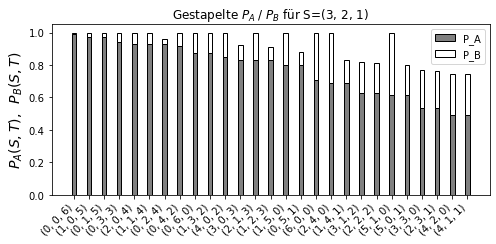

In [2]:
from fractions import Fraction
import PropSetzstrategien  as ps
# ========= Eingaben =================

"""
    Visualisiert gestapelte Balkendiagramme für P_A(S,T) und P_B(S,T)
    für eine feste Strategie S über alle Gegner-Strategien T.

    Args:
        S (tuple[int]): Fixe Strategie von A.
        p_vals (list[float] or list[Fraction]): Wahrscheinlichkeiten p_i.
        xlabel, ylabel, title (str): Achsenbeschriftungen und Titel.
        width (float): Breite der Balken (Empfehlung: 0.6 bis 1.0).
        sort_by (str): 'PA' oder 'PB'; sortiert nach absteigenden Werten.
        save_pdf (str): Dateiname, um die Grafik als PDF zu speichern.
        csv_path (str): Dateiname, um Ergebnisse in CSV zu speichern.
"""

# === Eingabe der Wahrscheinlichkeiten =======
p = (1/2,1/3,1/6)

# Eigabe der Setzstrategie S, die gegen alle
# anderen Setzstrategien spielt

S = (3,2,1)

# ==== Sicherheits-Check  ==================
#`exact=False`: falls numerisch
ps.p_list = ps.prepare_p_list(p, exact=True)
assert len(ps.p_list) == len(S), "p_list und V müssen dieselbe Länge haben!"

# ==== Grafik ============================
# Sortiert nach PB, speichert PDF und CSV
# ab 28 Strategien sollte plot=False (kein Plot) gewählt werden,
# da die Beschriftungen auf der x-Achse sich dann überlappen

ps.P_fixiert(
    S, p,
    xlabel="",
    ylabel=fr"$P_A(S,T), \;\; P_B(S,T)$",
    title=fr"Gestapelte $P_A\; / \;P_B$ für S={S}",
    width=0.3,
    sort_by='PA',
    save_pdf="stacked_PA_PB.pdf",
    breite=7,
    hoehe=3.5,
    csv_path="results_PA_PB.csv",
    plot=True    # plot=False: kein Plot
)